Notebook to place a pattern on a FIB image

In [38]:
# general
from copy import deepcopy

# for display
import napari
import matplotlib.pyplot as plt
import tifffile

# for the fibsem structures
from fibsem.structures import FibsemImage
from fibsem.patterning import FibsemMillingStage, get_milling_stages, TrenchPattern
from fibsem.microscope import FibsemMicroscope
from fibsem.patterns.ui import draw_milling_patterns

# for drawing patterns
from fibsem.ui.utils import _draw_patterns_in_napari
from fibsem import milling

# Set up test microscope
from fibsem import utils, acquire

# Adaptive polishing
from adaptive_polish import gis_measurement as gm
gm.init_model_with_path(model_path=r"C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\adaptive_polish\src\adaptive_polish\dl_segmentation\2024-02-24_0013_gis_lamela_crack_pytorch_AUnet.ptchkp")

2024-12-19 15:02:56,487 — root — INFO — __init__:174 — model path:C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\adaptive_polish\src\adaptive_polish\dl_segmentation\2024-02-24_0013_gis_lamela_crack_pytorch_AUnet.ptchkp
2024-12-19 15:02:56,489 — root — INFO — __init__:180 — DL device: cuda


C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\adaptive_polish\src\adaptive_polish\dl_segmentation\sem_lamella_segmentor.py:121: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues

In [44]:
# Set up test microscope
config_path = r"C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\fibsem\fibsem\config\microscope-configuration-demo2.yaml"
protocol_path = r"C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\adaptive_polish\src\adaptive_polish\scripts\spoof_microscope_protocol.yaml"
PIXEL_SIZE_M = 1.3020833333333335e-08 * 2  # actual images are 3072x2048 px but the config is set to half this size

microscope, settings = utils.setup_session(config_path=config_path, protocol_path=protocol_path)

2024-12-19 15:09:41,234 — root — INFO — connect_to_microscope:5403 — Microscope client connected to DemoMicroscope with serial number 123456 and software version 0.1
2024-12-19 15:09:41,235 — root — INFO — setup_session:218 — Finished setup for session: openfibsem_2024-12-19-03-09-41PM


In [50]:
# "Acquire" images
eb_image, ib_image = acquire.take_reference_images(microscope, settings.image)

2024-12-19 15:13:46,147 — root — INFO — acquire_image:6383 — acquiring new ELECTRON image.
2024-12-19 15:13:46,147 — root — INFO — acquire_image:6384 — resolution:[1536, 1024], hfw:4e-05
2024-12-19 15:13:46,149 — root — INFO — acquire_image:6391 — SEM
2024-12-19 15:13:46,150 — root — INFO — load:141 — Loading C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\2024segmentation_testdata\SEM\02A_SEM_mill.tif as spoof image
2024-12-19 15:13:50,930 — root — INFO — acquire_image:6418 — img_data.type:<class 'numpy.ndarray'>
2024-12-19 15:13:50,931 — root — INFO — acquire_image:6419 — img_data.dtype:uint8, img_data.shape:(2048, 3072)
2024-12-19 15:13:50,932 — root — INFO — acquire_image:6423 — demo image has shape:(2048, 3072). Resizing to (np.int64(1024), np.int64(1536))
2024-12-19 15:13:51,142 — root — INFO — acquire_image:6427 — Resized, img_data.dtype:uint8, img_data.shape:(1024, 1536)
2024-12-19 15:13:51,143 — root — INFO — acquire_image:6441 — data_uint

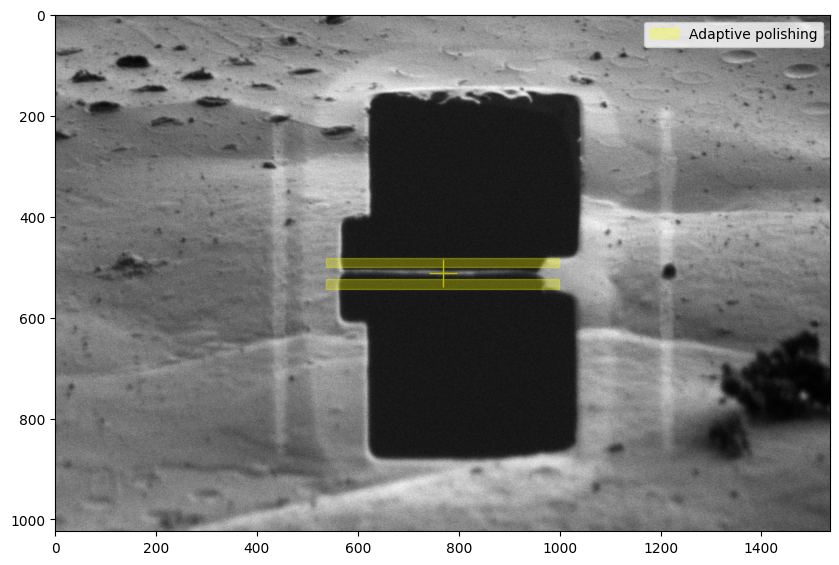

In [51]:
# Place pattern on FIB image from original protocol.yaml file
stages = get_milling_stages("lamella", settings.protocol["milling"])
fig = draw_milling_patterns(ib_image, stages)

2024-12-19 15:14:00,132 — root — INFO — get_prepreds_tfms:59 — imgsize:(1024, 1536), new_size:[512, 768]
2024-12-19 15:14:00,163 — root — INFO — get_prediction:210 — data1.shape:torch.Size([1, 512, 768])
2024-12-19 15:14:00,182 — root — INFO — get_prediction:218 — pred0.shape:torch.Size([1, 4, 512, 768])
2024-12-19 15:14:00,436 — root — INFO — clean_prediction:91 — clean_prediction with prediction.shape:(1024, 1536), pixel_size_m:2.604166666666667e-08
2024-12-19 15:14:00,469 — root — INFO — measure_GIS:118 — window_size_px: 3
2024-12-19 15:14:00,472 — root — INFO — milling_cycle_plot:201 — milling_cycle_plot()
Lamella width is 9.401041666666667e-06 m


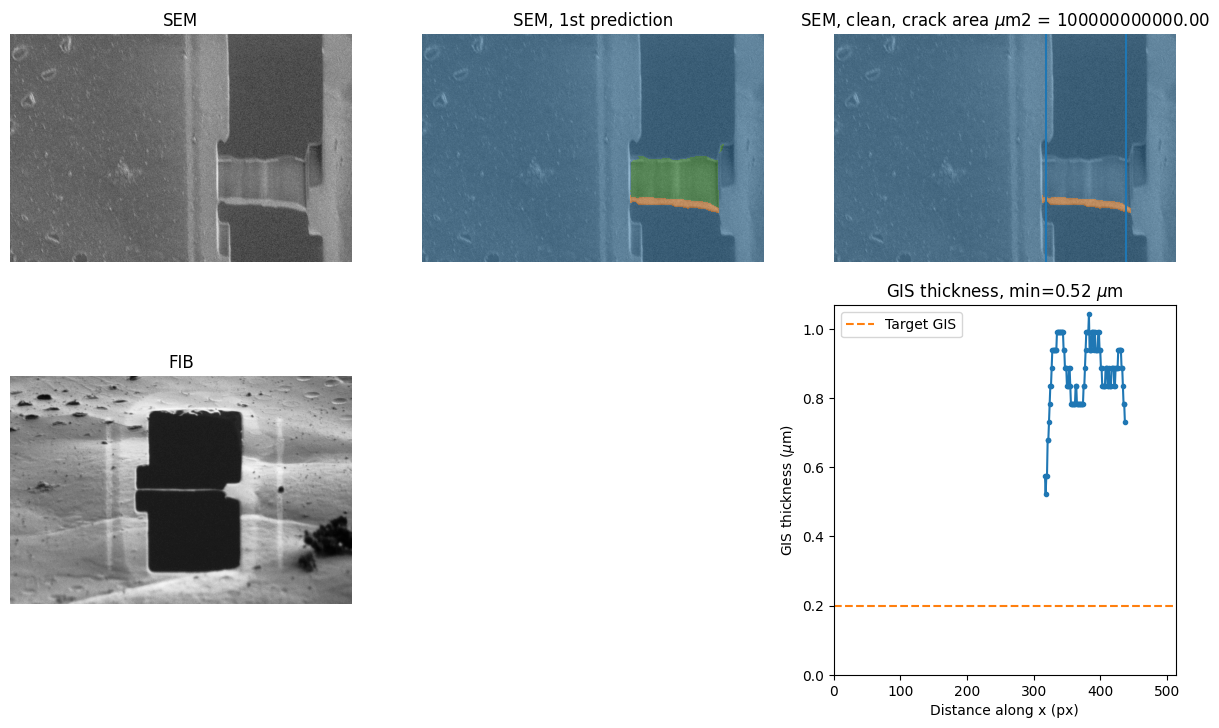

In [52]:
# Find the lamella width based on SEM image segmentation
prediction = gm.segment(eb_image.data)
clean_prediction = gm.clean_prediction(prediction=prediction, pixel_size_m=PIXEL_SIZE_M)
gis_thickness_m, xlims = gm.measure_GIS(mask_gis_clean=clean_prediction, window_size_m=1e-7, pixel_size_m=PIXEL_SIZE_M)
gm.milling_cycle_plot(
    sem_image=eb_image.data,
    first_prediction=prediction,
    clean_prediction=clean_prediction,
    fib_image=ib_image.data,
    gis_thickness_m=gis_thickness_m,
    gis_stop_m=2e-7,
    crack_area_m2=0.1,
    xlims=xlims,
    fib_screenshot=None,  # need to figure out how to pass this to plot,
    )
lamella_width = (xlims[1] - xlims[0]) * PIXEL_SIZE_M
print(f"Lamella width is {lamella_width} m")

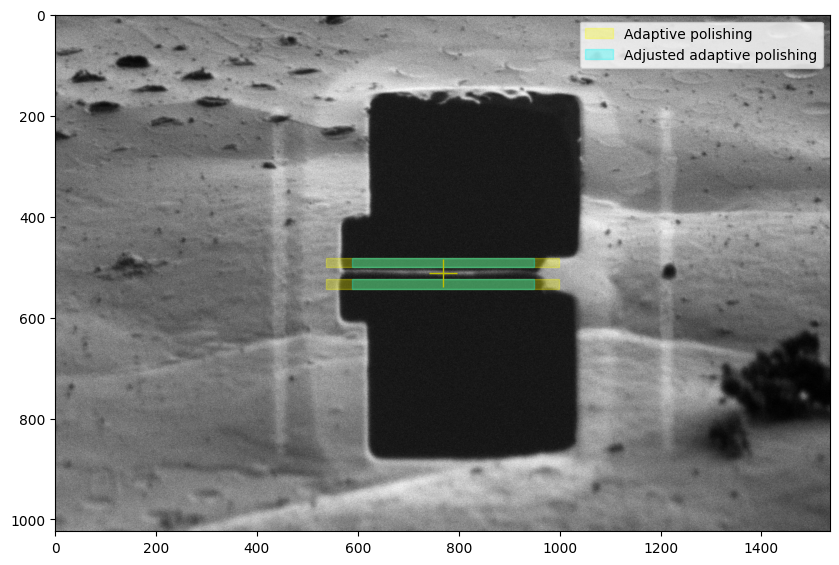

In [53]:
# Place pattern on image from edited pattern
ap_milling_protocol = deepcopy(settings.protocol["milling"]["lamella"]["stages"][-1])
ap_milling_protocol["lamella_width"] = lamella_width
ap_milling_protocol["hfw"] = 4e-05
ap_milling_protocol["trench_height"] = 5e-7
ap_milling_protocol["name"] = "Adjusted adaptive polishing"
if settings.protocol["milling"]["lamella"]["stages"][-1]["name"] == "Adaptive polishing":
    settings.protocol["milling"]["lamella"]["stages"].append(ap_milling_protocol)
elif settings.protocol["milling"]["lamella"]["stages"][-1]["name"] == "Adjusted adaptive polishing":
    settings.protocol["milling"]["lamella"]["stages"][-1] = ap_milling_protocol
stages = get_milling_stages("lamella", settings.protocol["milling"])
fig = draw_milling_patterns(ib_image, stages)